# Track 1 / 2 / 4 — Causal Analysis
**LM Dictionary + FinBERT + Sentence-BERT → CAR around earnings announcements**

Pipeline:
1. Load data
2. Compute CAR[-1,+1] and CAR[-3,+3] (market-adjusted)
3. Merge all text features
4. Z-score standardise
5. OLS panel regressions (industry + year FE, firm-clustered SE)
6. Plots

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA = 'data'   # relative to this notebook's folder

## 1. Load Data

In [3]:
panel   = pd.read_parquet(f'{DATA}/master_panel.parquet')
lm      = pd.read_parquet(f'{DATA}/lm_scores.parquet')
finbert = pd.read_parquet(f'{DATA}/finbert_scores.parquet')
embed   = pd.read_parquet(f'{DATA}/embed_similarity.parquet')
crsp    = pd.read_parquet(f'{DATA}/crsp_daily.parquet')
mkt     = pd.read_parquet(f'{DATA}/crsp_market.parquet')

panel['rdq']      = pd.to_datetime(panel['rdq'])
panel['datadate'] = pd.to_datetime(panel['datadate'])
crsp['date']      = pd.to_datetime(crsp['date'])
mkt['date']       = pd.to_datetime(mkt['date'])

print(f'Panel:   {len(panel):,} firm-years, {panel["ticker"].nunique():,} firms')
print(f'CRSP:    {len(crsp):,} daily obs')
panel.head(3)

Panel:   11,269 firm-years, 1,113 firms
CRSP:    3,488,808 daily obs


,gvkey,permno,cik,ticker,sic,fyear,datadate,date_filed,rdq,accession_no,s3_key,mda_len,log_assets,log_mktcap,bm_ratio,roa,leverage
0,001004,54594.0,0000001750,AIR,5080,2010,2011-05-31,2010-07-16,2011-07-06,0001047469-10-006500,10k-project/filings/AIR/2010/00010474691000650...,-1,7.440573,6.956375,0.796179,0.040984,0.193577
1,001004,54594.0,0000001750,AIR,5080,2011,2012-05-31,2011-07-13,2012-07-17,0001047469-11-006302,10k-project/filings/AIR/2011/00010474691100630...,-1,7.694235,6.184746,1.781717,0.030844,0.304916
2,001004,54594.0,0000001750,AIR,5080,2012,2013-05-31,2012-07-19,2013-07-25,0001047469-12-007300,10k-project/filings/AIR/2012/00010474691200730...,-1,7.667111,6.672037,1.162781,0.025738,0.291169


## 2. Compute CAR (Cumulative Abnormal Returns)

Abnormal return = firm daily return − market value-weighted return  
CAR[-1,+1]: sum over 3 trading days around earnings announcement date (`rdq`)

In [4]:
# Market-adjusted abnormal return
crsp = crsp.merge(mkt[['date', 'mkt_ret']], on='date', how='left')
crsp['abret'] = crsp['ret'] - crsp['mkt_ret']
crsp_sorted = crsp.sort_values(['permno', 'date']).reset_index(drop=True)

def car_for_panel(panel_df, window=(-1, 1)):
    results = []
    for permno, grp in panel_df.groupby('permno'):
        firm_crsp = crsp_sorted[crsp_sorted['permno'] == permno].reset_index(drop=True)
        if firm_crsp.empty:
            results.extend([np.nan] * len(grp))
            continue
        dates = firm_crsp['date'].values
        for rdq in grp['rdq'].values:
            if pd.isna(rdq):
                results.append(np.nan)
                continue
            idx = np.searchsorted(dates, rdq)
            lo, hi = idx + window[0], idx + window[1] + 1
            if lo < 0 or hi > len(dates):
                results.append(np.nan)
            else:
                results.append(firm_crsp.iloc[lo:hi]['abret'].sum())
    return results

panel_rdq = panel.dropna(subset=['rdq', 'permno']).sort_values(['permno', 'rdq']).reset_index(drop=True)

print('Computing CAR[-1,+1]...')
panel_rdq['car_1_1'] = car_for_panel(panel_rdq, (-1, 1))
print('Computing CAR[-3,+3]...')
panel_rdq['car_3_3'] = car_for_panel(panel_rdq, (-3, 3))

n = panel_rdq['car_1_1'].notna().sum()
print(f'\nCAR computed for {n:,} firm-years ({n/len(panel_rdq):.1%})')
panel_rdq[['car_1_1', 'car_3_3']].describe().round(4)

Computing CAR[-1,+1]...
Computing CAR[-3,+3]...

CAR computed for 11,230 firm-years (99.7%)


,car_1_1,car_3_3
count,11230.0000,11230.0000
mean,0.0041,0.0041
std,0.0667,0.0773
min,-0.4779,-0.7553
25%,-0.0303,-0.0361
50%,0.0020,0.0027
75%,0.0370,0.0428
max,0.7566,0.7318


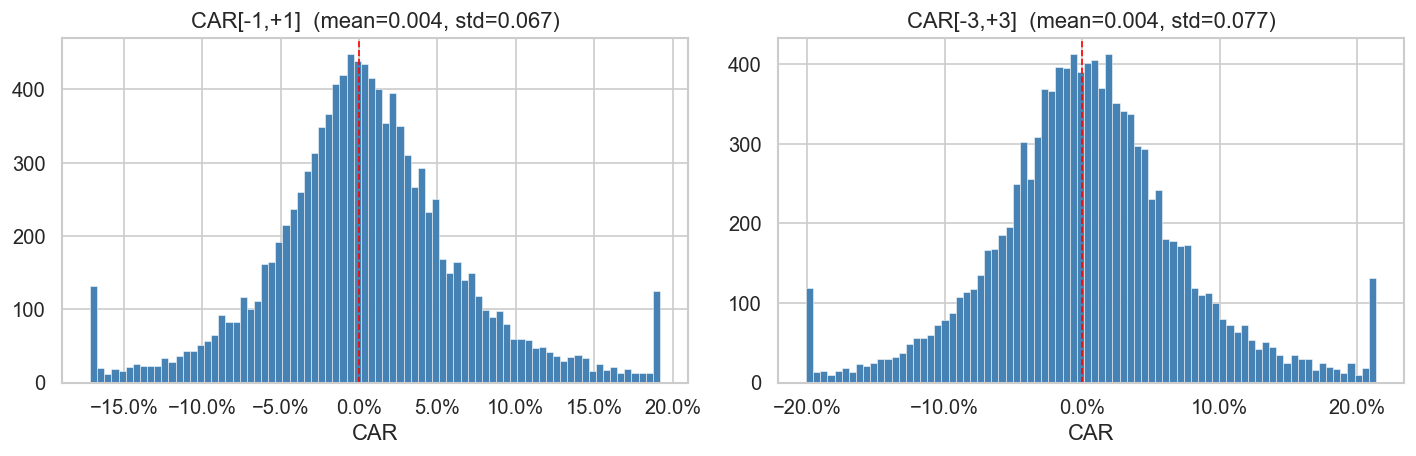

In [5]:
# Distribution of CAR[-1,+1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(axes,
                          ['car_1_1', 'car_3_3'],
                          ['CAR[-1,+1]', 'CAR[-3,+3]']):
    data = panel_rdq[col].dropna()
    data_clipped = data.clip(*data.quantile([0.01, 0.99]))
    ax.hist(data_clipped, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{label}  (mean={data.mean():.3f}, std={data.std():.3f})')
    ax.set_xlabel('CAR')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))

plt.tight_layout()
plt.show()

## 3. Merge Track Features

In [6]:
df = (panel_rdq
      .merge(lm,      on=['gvkey', 'fyear'], how='left')
      .merge(finbert, on=['gvkey', 'fyear'], how='left')
      .merge(embed,   on=['gvkey', 'fyear'], how='left'))

print(f'Merged dataset: {len(df):,} rows')
df[['lm_tone', 'fb_net', 'embed_novelty', 'car_1_1']].describe().round(4)

Merged dataset: 11,263 rows


,lm_tone,fb_net,embed_novelty,car_1_1
count,10837.0000,11263.0000,10154.0000,11230.0000
mean,-0.3983,-0.1073,0.0358,0.0041
std,0.2646,0.1438,0.0710,0.0667
min,-1.0000,-0.9442,-0.0000,-0.4779
25%,-0.5660,-0.2004,0.0107,-0.0303
50%,-0.4141,-0.0937,0.0158,0.0020
75%,-0.2473,-0.0115,0.0258,0.0370
max,1.0000,0.7805,0.8410,0.7566


## 4. Z-score Standardise All Features

In [7]:
# Note on variable selection (avoid perfect multicollinearity):
#   Track 1: lm_tone (net sentiment) + lm_uncertainty_pct
#   Track 2: fb_net only  (fb_pos + fb_neg + fb_neu = 1 by construction)
#   Track 4: embed_novelty only  (novelty = 1 - cos_sim)

TEXT_VARS    = ['lm_tone', 'lm_uncertainty_pct', 'fb_net', 'embed_novelty']
CONTROL_VARS = ['log_assets', 'log_mktcap', 'bm_ratio', 'roa', 'leverage']

for col in TEXT_VARS + CONTROL_VARS:
    df[f'{col}_z'] = stats.zscore(df[col], nan_policy='omit')

df['sic2']  = df['sic'].astype(str).str[:2]
df['fyear'] = df['fyear'].astype(str)

REG_VARS = ['car_1_1', 'car_3_3'] + [f'{c}_z' for c in TEXT_VARS + CONTROL_VARS]
df_reg = df.dropna(subset=REG_VARS).copy()
print(f'Regression sample: {len(df_reg):,} firm-years')

Regression sample: 9,735 firm-years


## 5. Correlation Heatmap

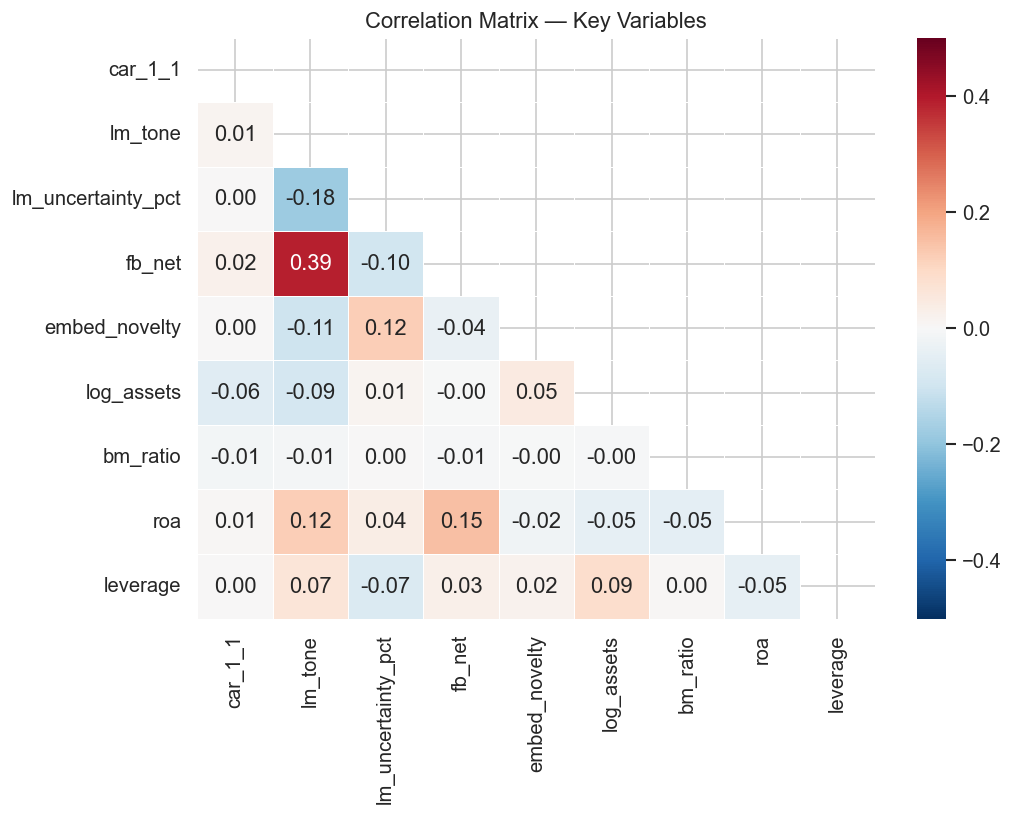

In [8]:
corr_vars = ['car_1_1', 'lm_tone', 'lm_uncertainty_pct', 'fb_net', 'embed_novelty',
             'log_assets', 'bm_ratio', 'roa', 'leverage']
corr = df_reg[[v for v in corr_vars if v in df_reg.columns]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.5, vmax=0.5, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Key Variables')
plt.tight_layout()
plt.show()

## 6. OLS Panel Regressions
- Fixed effects: industry (2-digit SIC) + year
- Standard errors: clustered at firm (gvkey) level

In [9]:
CTRL_Z = ' + '.join(f'{c}_z' for c in CONTROL_VARS)
FE     = 'C(fyear) + C(sic2)'

def run_ols(formula, data):
    return smf.ols(formula, data=data).fit(
        cov_type='cluster', cov_kwds={'groups': data['gvkey']})

def show_model(model, name):
    skip = ['Intercept']
    rows = []
    for var in model.params.index:
        if any(var.startswith(s) for s in ['Intercept', 'C(']):
            continue
        p = model.pvalues[var]
        stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
        rows.append({'Variable': var,
                     'Coef': model.params[var],
                     'SE':   model.bse[var],
                     't':    model.tvalues[var],
                     'p':    p,
                     'Sig':  stars})
    tbl = pd.DataFrame(rows).set_index('Variable')
    print(f'\n── {name}  |  R²={model.rsquared:.3f}  N={int(model.nobs):,} ──')
    print(tbl.to_string(float_format='{:.4f}'.format))
    return tbl

In [10]:
# Model 1: Track 1 – LM Dictionary
m1 = run_ols(f'car_1_1 ~ lm_tone_z + lm_uncertainty_pct_z + {CTRL_Z} + {FE}', df_reg)
t1 = show_model(m1, 'M1: LM Dictionary')


── M1: LM Dictionary  |  R²=0.020  N=9,735 ──
                        Coef     SE       t      p  Sig
Variable                                               
lm_tone_z             0.0014 0.0007  1.9633 0.0496   **
lm_uncertainty_pct_z  0.0004 0.0007  0.5844 0.5589     
log_assets_z         -0.0010 0.0019 -0.5354 0.5924     
log_mktcap_z         -0.0027 0.0019 -1.4724 0.1409     
bm_ratio_z           -0.0009 0.0001 -7.7683 0.0000  ***
roa_z                 0.0002 0.0009  0.1797 0.8574     
leverage_z            0.0015 0.0010  1.5286 0.1264     


In [11]:
# Model 2: Track 2 – FinBERT
m2 = run_ols(f'car_1_1 ~ fb_net_z + {CTRL_Z} + {FE}', df_reg)
t2 = show_model(m2, 'M2: FinBERT')


── M2: FinBERT  |  R²=0.020  N=9,735 ──
                Coef     SE       t      p  Sig
Variable                                       
fb_net_z      0.0018 0.0007  2.5139 0.0119   **
log_assets_z -0.0008 0.0019 -0.4087 0.6827     
log_mktcap_z -0.0030 0.0018 -1.6253 0.1041     
bm_ratio_z   -0.0009 0.0001 -7.8733 0.0000  ***
roa_z         0.0001 0.0009  0.0952 0.9241     
leverage_z    0.0015 0.0010  1.4531 0.1462     


In [12]:
# Model 3: Track 4 – Sentence-BERT novelty
m3 = run_ols(f'car_1_1 ~ embed_novelty_z + {CTRL_Z} + {FE}', df_reg)
t3 = show_model(m3, 'M3: SBERT Novelty')


── M3: SBERT Novelty  |  R²=0.019  N=9,735 ──
                   Coef     SE       t      p  Sig
Variable                                          
embed_novelty_z  0.0003 0.0006  0.4683 0.6396     
log_assets_z    -0.0015 0.0019 -0.8226 0.4107     
log_mktcap_z    -0.0022 0.0018 -1.2010 0.2297     
bm_ratio_z      -0.0009 0.0001 -7.5977 0.0000  ***
roa_z            0.0002 0.0009  0.2254 0.8217     
leverage_z       0.0015 0.0010  1.4665 0.1425     


In [13]:
# Model 4: All tracks combined
m4 = run_ols(f'car_1_1 ~ lm_tone_z + lm_uncertainty_pct_z + fb_net_z + embed_novelty_z + {CTRL_Z} + {FE}', df_reg)
t4 = show_model(m4, 'M4: All Tracks')


── M4: All Tracks  |  R²=0.020  N=9,735 ──
                        Coef     SE       t      p  Sig
Variable                                               
lm_tone_z             0.0008 0.0007  1.1264 0.2600     
lm_uncertainty_pct_z  0.0004 0.0007  0.5810 0.5612     
fb_net_z              0.0015 0.0008  2.0165 0.0438   **
embed_novelty_z       0.0004 0.0007  0.5880 0.5565     
log_assets_z         -0.0006 0.0019 -0.3205 0.7486     
log_mktcap_z         -0.0032 0.0019 -1.7193 0.0856    *
bm_ratio_z           -0.0009 0.0001 -7.9170 0.0000  ***
roa_z                 0.0001 0.0009  0.0912 0.9274     
leverage_z            0.0015 0.0010  1.5024 0.1330     


In [14]:
# Model 5: Robustness check with CAR[-3,+3]
df_rob = df.dropna(subset=['car_3_3'] + [f'{c}_z' for c in TEXT_VARS + CONTROL_VARS]).copy()
m5 = run_ols(f'car_3_3 ~ lm_tone_z + lm_uncertainty_pct_z + fb_net_z + embed_novelty_z + {CTRL_Z} + {FE}', df_rob)
t5 = show_model(m5, 'M5: Robustness CAR[-3,+3]')


── M5: Robustness CAR[-3,+3]  |  R²=0.019  N=9,735 ──
                        Coef     SE       t      p Sig
Variable                                              
lm_tone_z             0.0015 0.0008  1.9266 0.0540   *
lm_uncertainty_pct_z  0.0003 0.0008  0.3789 0.7047    
fb_net_z              0.0006 0.0009  0.7076 0.4792    
embed_novelty_z       0.0010 0.0008  1.2092 0.2266    
log_assets_z         -0.0016 0.0026 -0.6075 0.5435    
log_mktcap_z         -0.0021 0.0027 -0.7822 0.4341    
bm_ratio_z           -0.0005 0.0004 -1.5428 0.1229    
roa_z                 0.0002 0.0010  0.1925 0.8473    
leverage_z            0.0026 0.0012  2.1410 0.0323  **


## 7. Coefficient Plot (Model 4 – All Tracks)

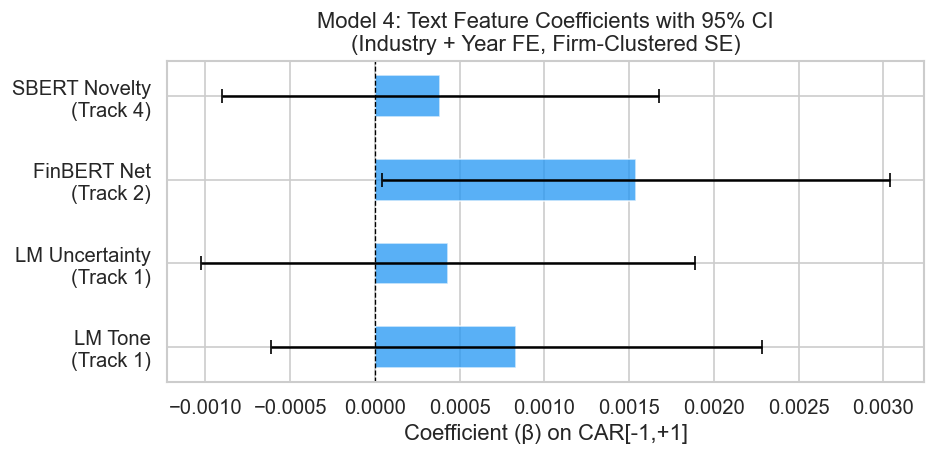

In [15]:
text_vars_z = ['lm_tone_z', 'lm_uncertainty_pct_z', 'fb_net_z', 'embed_novelty_z']
labels = ['LM Tone\n(Track 1)', 'LM Uncertainty\n(Track 1)',
          'FinBERT Net\n(Track 2)', 'SBERT Novelty\n(Track 4)']

coefs = m4.params[text_vars_z]
cis   = m4.conf_int().loc[text_vars_z]
colors = ['#2196F3' if c > 0 else '#F44336' for c in coefs]

fig, ax = plt.subplots(figsize=(8, 4))
for i, (var, label) in enumerate(zip(text_vars_z, labels)):
    ax.barh(i, coefs[var], color=colors[i], alpha=0.75, height=0.5)
    ax.errorbar(coefs[var], i,
                xerr=[[coefs[var] - cis.loc[var, 0]],
                      [cis.loc[var, 1] - coefs[var]]],
                fmt='none', color='black', capsize=4, linewidth=1.5)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient (β) on CAR[-1,+1]')
ax.set_title('Model 4: Text Feature Coefficients with 95% CI\n(Industry + Year FE, Firm-Clustered SE)')
plt.tight_layout()
plt.show()

## 8. CAR by Text Sentiment Quintile

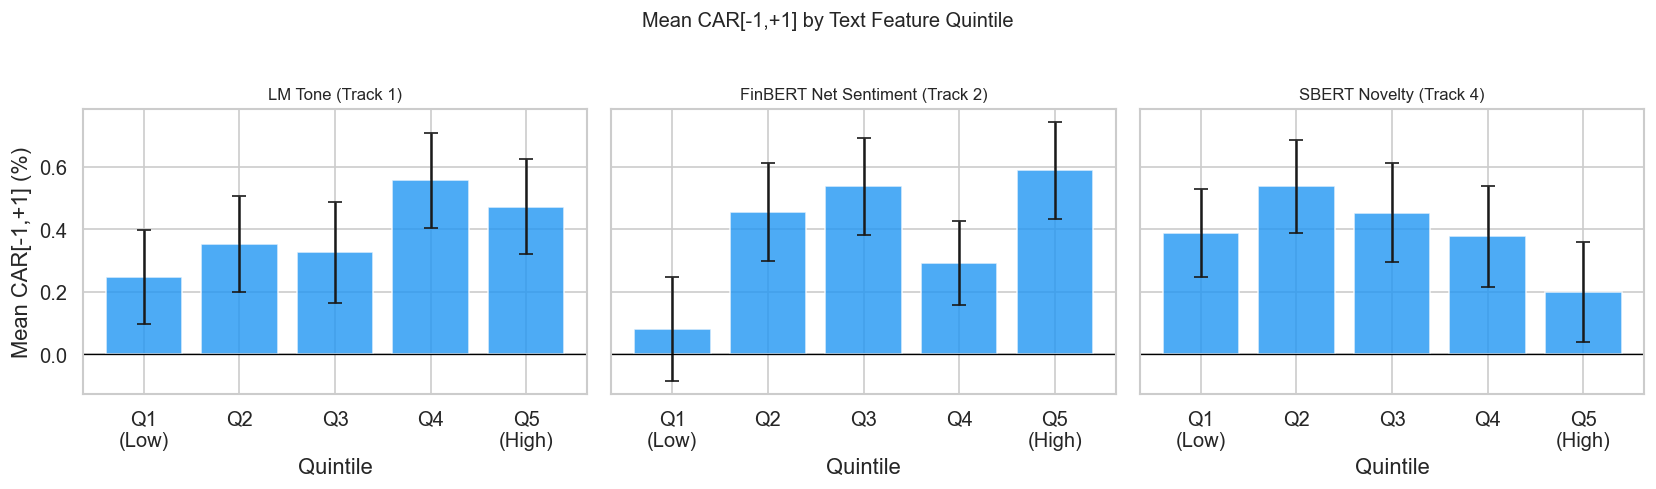

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, var, label in zip(axes,
                          ['lm_tone', 'fb_net', 'embed_novelty'],
                          ['LM Tone (Track 1)', 'FinBERT Net Sentiment (Track 2)', 'SBERT Novelty (Track 4)']):
    df_plot = df_reg.dropna(subset=[var, 'car_1_1']).copy()
    df_plot['quintile'] = pd.qcut(df_plot[var], 5, labels=['Q1\n(Low)', 'Q2', 'Q3', 'Q4', 'Q5\n(High)'])
    means = df_plot.groupby('quintile', observed=True)['car_1_1'].mean() * 100
    sems  = df_plot.groupby('quintile', observed=True)['car_1_1'].sem()  * 100
    colors = ['#F44336' if m < 0 else '#2196F3' for m in means]
    ax.bar(means.index, means, yerr=sems, color=colors, alpha=0.8,
           edgecolor='white', capsize=4)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Quintile')
    if ax == axes[0]:
        ax.set_ylabel('Mean CAR[-1,+1] (%)')

plt.suptitle('Mean CAR[-1,+1] by Text Feature Quintile', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 9. Save Results

In [17]:
all_results = []
for tbl, name in [(t1,'M1: LM Dict'), (t2,'M2: FinBERT'),
                  (t3,'M3: SBERT'),   (t4,'M4: All'),  (t5,'M5: CAR[-3,+3]')]:
    tbl = tbl.copy()
    tbl['Model'] = name
    all_results.append(tbl.reset_index())

out = pd.concat(all_results, ignore_index=True)
out.to_csv(f'{DATA}/regression_results_124.csv', index=False)
print('✓ Saved regression_results_124.csv')

df_reg.to_parquet(f'{DATA}/analysis_panel.parquet', index=False)
print('✓ Saved analysis_panel.parquet  (ready for Track 3 merge)')

✓ Saved regression_results_124.csv
✓ Saved analysis_panel.parquet  (ready for Track 3 merge)
